# QWT–JEPA — p26_ijepa: phase 1 là I-JEPA, không có gì khác

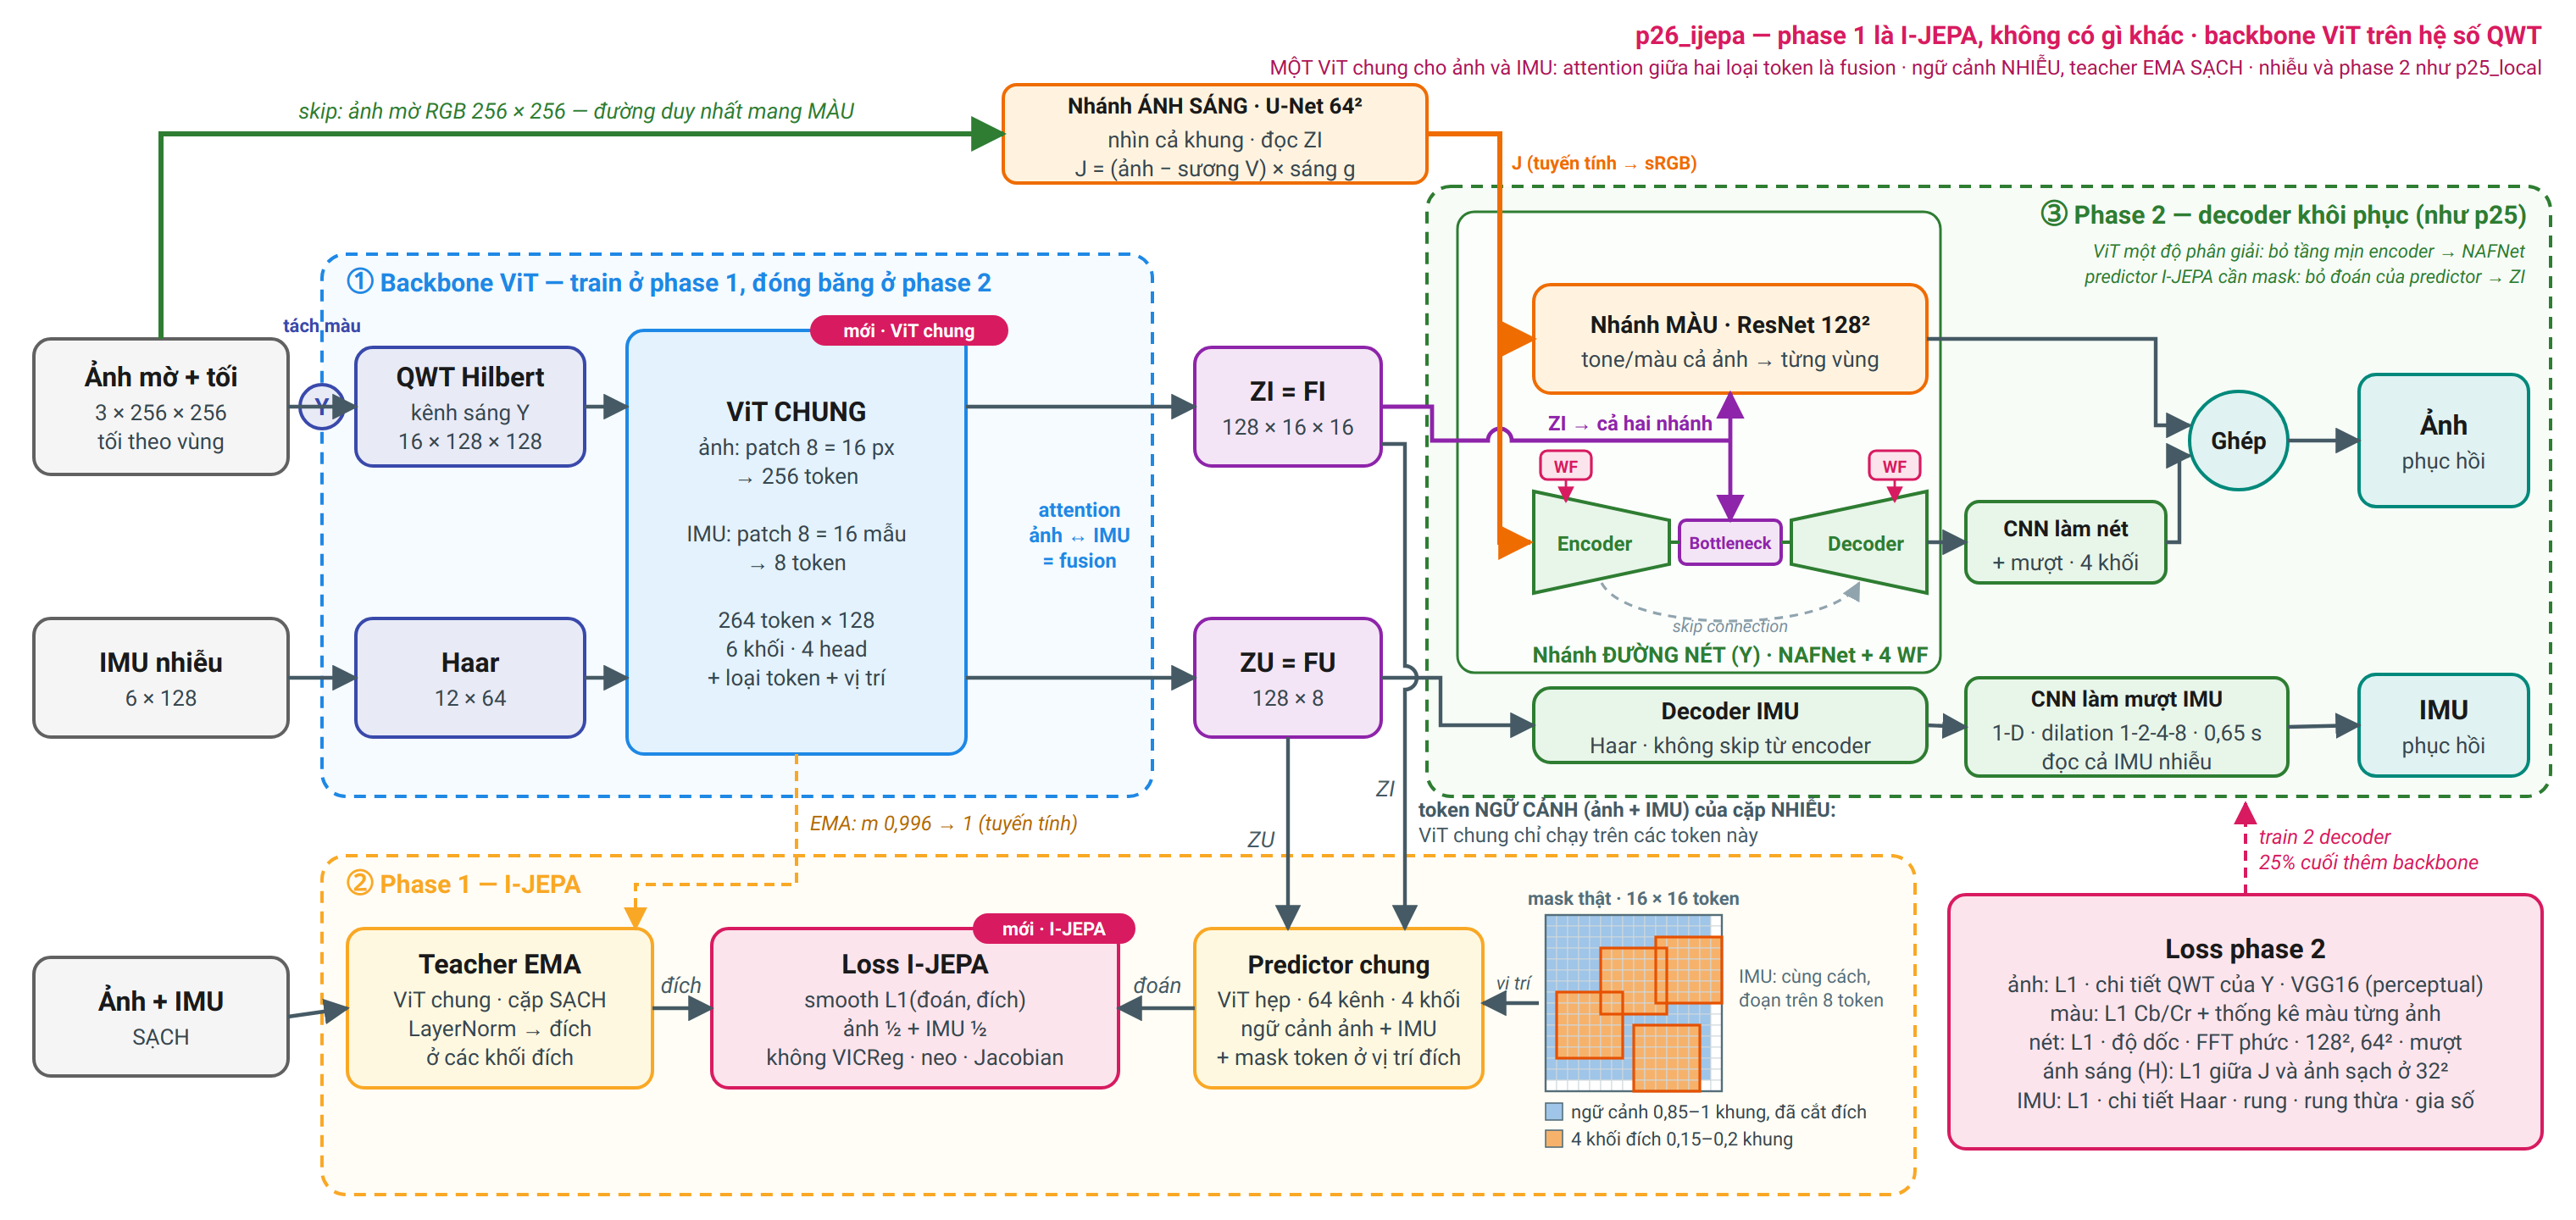

Hình: `docs/kien_truc_ijepa.svg`, vẽ lại bằng `python3 tools/draw_architecture_ijepa.py docs/kien_truc_ijepa.svg`.
Ô mask trong hình là một mask thật do chính code sinh ra từ `configs/kaggle_ijepa.yaml`.

**① Backbone: một ViT chung cho ảnh và IMU.** Ảnh RGB 256 × 256 → kênh sáng Y → QWT Hilbert (16 × 128 × 128) →
patch 8 hệ số (= 16 px ảnh) → 256 token. IMU 6 × 128 → Haar (12 × 64) → patch 8 → 8 token. Mỗi loại có nhúng patch, vị
trí và embedding loại token riêng, rồi cả **264 token đi chung qua một ViT** (6 khối, 4 head, 128 kênh). Attention giữa
token ảnh và token IMU **chính là fusion**, train bằng đúng loss I-JEPA, nên không còn module fusion riêng: ZI = FI,
ZU = FU, nhưng ZI đã "nghe" IMU và ZU đã "nhìn" ảnh. Đúng lưới của CNN cũ, nên decoder phase 2 đọc ZI 128 × 16 × 16 và
ZU 128 × 8 như trước.

**② Phase 1 = I-JEPA** (Assran 2023), không có số hạng nào khác — không VICReg, không decoder neo, không Jacobian,
không InfoNCE, không đích đa tỉ lệ:
- Mỗi batch một cỡ khối đích (15–20% khung, tỉ lệ cạnh 0,75–1,5) và một cỡ khối ngữ cảnh (85–100%). Mỗi mẫu có 4 khối
  đích và 1 khối ngữ cảnh đã cắt bỏ đích, rút riêng cho ảnh (khối trên lưới 16 × 16) và cho IMU (đoạn trên 8 token);
  ngữ cảnh là cả hai. Trên lưới ảnh 16 × 16, ngữ cảnh còn trung vị 42% số token.
- **Encoder ngữ cảnh** (chính ViT chung online) chỉ chạy trên token ngữ cảnh của ảnh và IMU **nhiễu**, trong một lượt.
- **Teacher EMA** (bản EMA của ViT chung) chạy trên cả cặp **sạch**; đầu ra qua LayerNorm là đích ở các khối đích.
- **Predictor chung** (ViT hẹp, 64 kênh, 4 khối) đọc token ngữ cảnh của cả ảnh lẫn IMU, đặt mask token (kèm vị trí và
  loại token) ở từng khối đích — của ảnh hay của IMU — mỗi khối một lượt.
- Loss: smooth L1 giữa dự đoán và đích, ảnh ½ + IMU ½. Weight decay cosine 0,04 → 0,4, EMA tăng tuyến tính 0,996 → 1,
  không cắt gradient, không lật ảnh.

**③ Phase 2** như p25_local (nhánh ánh sáng H, nhánh màu ResNet 128², nhánh đường nét NAFNet + 4 khối wavelet–Fourier,
decoder IMU + CNN làm mượt), chỉ bỏ hai đầu vào: các tầng mịn của encoder (ViT có một độ phân giải) và dự đoán của
predictor (predictor I-JEPA cần mask). Backbone đóng băng, 25% update cuối mở ra train cùng (LP-FT).

**Context hay target encoder cho phase 2.** I-JEPA đánh giá bằng target encoder (teacher EMA), nhưng trên ảnh sạch;
ở đây phase 2 đọc ảnh nhiễu. `phase2.backbone_weights` chọn trọng số phase 2 đóng băng: `RUN = 'p26_ijepa'` dùng
**context encoder** (online), `RUN = 'p26_ijepa_target'` dùng **target encoder** và lấy lại phase 1 của p26_ijepa
(cùng hash phase 1). Chạy p26_ijepa trước, rồi đổi `RUN` ở Cell 1 và Run All (cùng phiên, hoặc gắn archive của
p26_ijepa làm Input). Đo ở máy sau 1000 update, 512 cặp nhiễu: hai encoder gần như ngang nhau (ảnh 40,3% / 40,2%,
IMU 87,0% / 84,2% thông tin rút được), nên so bằng phase 2 thật.

**Chạy trên Kaggle:** GPU T4 × 2, gắn ba dataset `tartanairshard0`, `tartanairshard1`, `tartanairshard2` làm Input,
rồi **Run All** (`SOURCE_REF` ở Cell 1 đã ghim commit có I-JEPA). Mặc định phase 1 **2500** update và phase 2 **5000** update, bằng p25_local
để so thẳng (p25 hết khoảng 100 phút trên 2 × T4; p26 chưa đo trên Kaggle). Cell 8 in effective rank của latent qua
các lần kiểm: I-JEPA không có VICReg, nên rank tụt là dấu hiệu latent dồn về ít chiều (thử ở máy: ZI 5,3 → 2,6, ZU
23,5 → 8,0 sau 1000 update; probe tuyến tính vẫn rút được 52% ô ảnh và 80–88% IMU).

## Cell 1 — Source và các lựa chọn của phiên

In [ ]:
from pathlib import Path
import gc
import json
import os
import shutil
import subprocess
import sys
import time

cell_started = time.perf_counter()
INPUT = Path('/kaggle/input')
PROJECT = Path('/kaggle/working/qwt_jepa_version3')
REPO_URL = 'https://github.com/leesanghyoek/qwt_jepa_ver5.git'
# SHA commit tren ver5 main co I-JEPA (configs/kaggle_ijepa.yaml). Ghim de moi lan chay dung cung mot code.
SOURCE_REF = '95d2688'
RESUME_RUN = None  # Path('/kaggle/input/<archive-da-giai-nen>/outputs/p26_ijepa')
DATA_ROOT = None   # None: Cell 3 tu do (TartanAir 640: gop cac shard)
TARTANAIR640 = True
SHARDS = None      # du ba shard; thieu shard nao Cell 3 dung va bao ten
# 'p26_ijepa': phase 2 dong bang context encoder (online). 'p26_ijepa_target': phase 2 dong bang target encoder
# (teacher EMA) va dung lai phase 1 cua p26_ijepa (cung hash phase 1): chay p26_ijepa truoc, doi RUN, Run All.
RUN = 'p26_ijepa'
CONFIG_NAME = {'p26_ijepa': 'kaggle_ijepa.yaml', 'p26_ijepa_target': 'kaggle_ijepa_target.yaml'}[RUN]
P1_UPDATES = 2500  # bang p25_local de so thang
P2_UPDATES = 5000  # LP-FT tu dong o 75% (update 3750)
PRECISION = 'auto'  # phase 2. 'auto': Cell 4 do fp32 / fp16 tren T4 cua phien (~3 phut). Ep tay: 'amp_fp16' / 'fp32'.
RUN_TESTS = False   # chi bat khi doi source hoac can kiem thu day du
RUN_DIAGNOSTICS = True  # probe latent + D2 sau phase 1, delta report + D1 sau phase 2 (khong train, ~5 phut moi cai)
FULL_TEST = True        # danh gia 10 kich ban tren test; False = full/full tren validation
DATALOADER_WORKERS = 3  # T4 x2 co 4 vCPU; RAM gan day thi ha ve 2
PIN_MEMORY = True
GPU_COUNT = '2'   # phase 1 va phase 2 tren 2 GPU (DDP); danh gia luon 1 GPU. '1' = mot GPU.
PARALLEL = 'ddp'  # 2 GPU = 2 tien trinh: khong co race 'misaligned address' cua DataParallel
CUDNN = True

if RESUME_RUN is not None:
    RESUME_RUN = Path(RESUME_RUN)
    revision = RESUME_RUN / 'source_revision.txt'
    assert revision.is_file(), f'Thiếu {revision}'
    SOURCE_REF = revision.read_text().strip()
assert SOURCE_REF, 'Điền SOURCE_REF: SHA commit trên ver5 main có I-JEPA (configs/kaggle_ijepa.yaml).'

def git_output(*args):
    return subprocess.check_output(['git', '-C', str(PROJECT), *args], text=True).strip()

if not PROJECT.exists():
    subprocess.run(['git', 'clone', '--branch', 'main', REPO_URL, str(PROJECT)], check=True)
    subprocess.run(['git', '-C', str(PROJECT), 'checkout', '--detach', SOURCE_REF], check=True)
else:
    # PROJECT con lai tu lan chay truoc trong cung session: fetch va checkout lai, khong tin checkout cu.
    print('PROJECT da ton tai; fetch va checkout lai', SOURCE_REF)
    if git_output('remote', 'get-url', 'origin').removesuffix('.git') != REPO_URL.removesuffix('.git'):
        subprocess.run(['git', '-C', str(PROJECT), 'remote', 'set-url', 'origin', REPO_URL], check=True)
    subprocess.run(['git', '-C', str(PROJECT), 'fetch', '--no-tags', 'origin', 'main'], check=True)
    subprocess.run(['git', '-C', str(PROJECT), 'checkout', '--detach', SOURCE_REF], check=True)

assert (PROJECT / '.git').is_dir(), 'PROJECT không phải Git checkout; chọn session mới.'
assert git_output('remote', 'get-url', 'origin').removesuffix('.git') == REPO_URL.removesuffix('.git')
SOURCE_COMMIT = git_output('rev-parse', 'HEAD')
assert SOURCE_COMMIT == git_output('rev-parse', SOURCE_REF + '^{commit}'), (
    'Checkout khác SOURCE_REF. Dùng session mới; không đổi code giữa run.'
)
assert (PROJECT / 'configs' / CONFIG_NAME).is_file(), (
    f'Commit {SOURCE_REF} chưa có configs/{CONFIG_NAME}: SOURCE_REF phải là commit có I-JEPA.')
os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
os.environ['MPLCONFIGDIR'] = str(PROJECT / 'outputs/matplotlib_cache')
os.environ['PYTEST_DISABLE_PLUGIN_AUTOLOAD'] = '1'
(PROJECT / 'source_revision.txt').write_text(SOURCE_COMMIT + '\n', encoding='utf-8')
print('Source:', SOURCE_COMMIT)
print('Resume:', RESUME_RUN)
assert INPUT.is_dir() and any(INPUT.iterdir()), 'Chưa gắn dataset vào /kaggle/input.'
print('Inputs:', [p.name for p in sorted(INPUT.iterdir())])
print('Cell 1 giây:', round(time.perf_counter() - cell_started, 1))

## Cell 2 — Dependency và GPU; kiểm thử đầy đủ chỉ khi RUN_TESTS=True

In [ ]:
cell_started = time.perf_counter()
import importlib.util

packages = {
    'numpy': 'numpy>=1.24', 'PIL': 'Pillow>=10', 'yaml': 'PyYAML>=6',
    'scipy': 'scipy>=1.11', 'matplotlib': 'matplotlib>=3.7',
}
missing = [requirement for module, requirement in packages.items()
           if importlib.util.find_spec(module) is None]
if RUN_TESTS and importlib.util.find_spec('pytest') is None:
    missing.append('pytest>=8')
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', *missing], check=True)

import torch
# Python khong import lai module da nam trong sys.modules: xoa cache de chac nap dung checkout vua chon.
for _cached in [m for m in sys.modules if m == 'qjepa' or m.startswith('qjepa.')]:
    del sys.modules[_cached]
import qjepa
_qjepa_path = Path(qjepa.__file__).resolve()
assert _qjepa_path.is_relative_to(PROJECT.resolve()), (
    f'qjepa nap tu {_qjepa_path}, khong phai {PROJECT.resolve()}. '
    'Neu duong dan tro vao site-packages: !pip uninstall -y qwt-jepa-v3 roi restart kernel.'
)
assert torch.cuda.is_available(), 'Bật GPU rồi khởi động lại session notebook.'
print('Python:', sys.version)
print('Torch:', torch.__version__, 'CUDA runtime:', torch.version.cuda)
for index in range(torch.cuda.device_count()):
    properties = torch.cuda.get_device_properties(index)
    print(f'GPU {index}:', properties.name, '| VRAM GiB:', round(properties.total_memory / 2**30, 2))
print('GPU train:', GPU_COUNT, '| song song:', PARALLEL, '| cuDNN:', CUDNN, '| precision:', PRECISION)
assert torch.cuda.device_count() >= int(GPU_COUNT), (
    f'Cần {GPU_COUNT} GPU mà chỉ thấy {torch.cuda.device_count()}: chọn GPU T4 x2, hoặc đặt GPU_COUNT = "1".')
if RUN_TESTS:
    subprocess.run([sys.executable, '-m', 'pytest', '-q'], cwd=PROJECT, check=True)
else:
    print('Bỏ qua full pytest; bật RUN_TESTS ở Cell 1 nếu đổi source hoặc cần kiểm thử đầy đủ.')
import numpy as np
import yaml
import matplotlib.pyplot as plt
from IPython.display import display, Image as DisplayImage, FileLink
print('Cell 2 giây:', round(time.perf_counter() - cell_started, 1))

## Cell 3 — Dataset root và vài timeline

In [ ]:
cell_started = time.perf_counter()
from collections import Counter
from qjepa.data.tartanair import Trajectory, discover_trajectories, audit_trajectory

if TARTANAIR640:
    from qjepa.data.tartanair import find_shard_roots, link_trajectories
    # Moi shard la mot dataset, quy dao nam o do sau khac nhau. Thieu shard nao trong SHARDS thi dung.
    shard_roots = find_shard_roots(INPUT, shards=SHARDS)
    for shard, root in shard_roots.items():
        print('shard', shard, root)
    DATA_ROOT = link_trajectories(list(shard_roots.values()), Path('/tmp/tartanair640_all'))


def candidate_roots(base):
    # Khong duyet hang chuc nghin file anh khi do thu muc IMU.
    found = Counter()
    for directory, children, files in os.walk(base):
        children[:] = [name for name in children if name != 'image_lcam_front']
        if Path(directory).name != 'imu' or not {'imu_time.npy', 'imu_time.txt'} & set(files):
            continue
        trajectory = Path(directory).parent
        if (trajectory / 'image_lcam_front').is_dir() and len(trajectory.parents) >= 3:
            found[trajectory.parents[2]] += 1
    return found

if DATA_ROOT is None:
    counts = Counter()
    for mount in sorted(INPUT.iterdir()):
        if mount.is_dir():
            counts.update(candidate_roots(mount))
    assert counts, 'Không thấy trajectory nào; kiểm tra dataset đã gắn và đã giải nén.'
    for root, total in counts.most_common():
        print(f'{total:5d} trajectory  {root}')
    DATA_ROOT = counts.most_common(1)[0][0]
    if len(counts) > 1:
        print('Nếu root được chọn sai, đặt DATA_ROOT ở Cell 1 rồi chạy lại.')

DATA_ROOT = Path(DATA_ROOT)
assert DATA_ROOT.is_dir(), f'Thiếu dataset root: {DATA_ROOT}'
paths = {}
for pattern in ('*/*/*/imu/imu_time.npy', '*/*/*/imu/imu_time.txt'):
    for timeline in DATA_ROOT.glob(pattern):
        paths.setdefault(timeline.parent.parent, timeline)
if paths:
    trajectories = []
    for path in sorted(paths):
        assert (path / 'image_lcam_front').is_dir(), f'Thiếu ảnh: {path}'
        environment, difficulty, trajectory_id = path.relative_to(DATA_ROOT).parts
        trajectories.append(Trajectory(path, environment, difficulty, trajectory_id))
else:
    trajectories = discover_trajectories(DATA_ROOT)
keys = [trajectory.key for trajectory in trajectories]
assert keys and len(keys) == len(set(keys)), 'Không tìm thấy trajectory hoặc DATA_ROOT đang gộp bản sao.'
hints = {trajectory.split_hint for trajectory in trajectories}
assert len(hints) == 1, f'Split hint không đồng nhất {hints}; DATA_ROOT đang trỏ quá cao.'
print('DATA_ROOT:', DATA_ROOT, '| trajectory:', len(trajectories),
      '| motion key:', len({trajectory.motion_key for trajectory in trajectories}))
print('Difficulty:', dict(Counter(trajectory.difficulty for trajectory in trajectories)))
for trajectory in trajectories[:3]:
    print(audit_trajectory(trajectory, window=128))
del trajectories
gc.collect()
print('Cell 3 giây:', round(time.perf_counter() - cell_started, 1))

## Cell 4 — Cấu hình và resume

Recipe nằm trọn trong `configs/kaggle_ijepa.yaml`. Cell này chỉ ghi đè những gì thuộc về **phiên chạy**: số update,
đường dẫn, thiết bị, số worker và precision phase 2 do speed probe chọn — không ghi đè khoá recipe nào. Khi resume, dùng
nguyên config đã lưu trong archive; hash khác thì dừng và giữ checkpoint. `OUT` là nguồn duy nhất cho mọi đường dẫn sau.

In [ ]:
cell_started = time.perf_counter()
from qjepa.config import load_config, serializable_config, validate_config
from qjepa.training.checkpoints import configuration_hash, load_checkpoint, require_phase1_checkpoint

OUT = PROJECT / 'outputs' / RUN
MANIFEST = PROJECT / 'manifests/kaggle'
CONFIG = PROJECT / 'configs/kaggle.yaml'

config = serializable_config(load_config(PROJECT / 'configs' / CONFIG_NAME))
config['phase1']['max_successful_updates'] = P1_UPDATES
config['phase2']['max_successful_updates'] = P2_UPDATES
# Recipe: backbone train cung tu update 15000/20000. Doi so update thi giu ty le 75%.
config['phase2']['backbone_finetune_after_updates'] = int(0.75 * P2_UPDATES)
if RESUME_RUN is not None:
    saved = RESUME_RUN / 'config.yaml'
    assert saved.is_file(), 'Resume cần config.yaml đầy đủ trong archive của notebook này.'
    config = yaml.safe_load(saved.read_text())
    for phase in ('phase1', 'phase2'):
        resolved = RESUME_RUN / phase / 'resolved_config.yaml'
        if resolved.is_file():
            previous = yaml.safe_load(resolved.read_text())
            assert configuration_hash(previous, phase) == configuration_hash(config, phase), (
                f'Archive chứa config không khớp {phase}.')
    if not OUT.exists():
        # Resume chi can checkpoint, config va log; khong chep anh / eval cu.
        keep = ('config.yaml', 'source_revision.txt',
                'phase1/last.pt', 'phase1/train.jsonl', 'phase1/resolved_config.yaml',
                'phase2/last.pt', 'phase2/best_joint_validation.pt', 'phase2/best_blur_validation.pt',
                'phase2/best_guarded_validation.pt', 'phase2/train.jsonl', 'phase2/resolved_config.yaml',
                'phase2/guard_reference.json')
        restored = []
        for name in keep:
            source = RESUME_RUN / name
            if source.is_file():
                destination = OUT / name
                destination.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(source, destination)
                restored.append(name)
        print('Đã khôi phục file cần để resume:', restored)
    else:
        print('OUT đã tồn tại: dùng bản local; không ghi đè từ archive.')
if RUN == 'p26_ijepa_target' and RESUME_RUN is None and not (OUT / 'phase1/last.pt').is_file():
    # Chi doi phase 2: lay phase 1 cua p26_ijepa (/kaggle/working, hoac archive da giai nen gan lam Input).
    # Hash phase 1 cua hai config bang nhau; train_phase van kiem lai hash va manifest cua checkpoint.
    sources = [PROJECT / 'outputs/p26_ijepa'] + sorted(p.parent.parent for depth in ('*', '*/*', '*/*/*')
                                                    for p in INPUT.glob(f'{depth}/outputs/p26_ijepa/phase1/last.pt'))
    source = next((s for s in sources if (s / 'phase1/last.pt').is_file()), None)
    assert source is not None, ('p26_ijepa_target cần phase 1 của p26_ijepa: chạy RUN = "p26_ijepa" trước, '
                                'hoặc gắn archive đã giải nén của nó làm Input.')
    shutil.copytree(source / 'phase1', OUT / 'phase1', dirs_exist_ok=True)
    print('Dùng lại phase 1 của p26_ijepa từ', source)
# Kiem tra checkout, khong phai ghi de recipe: config phai dung la I-JEPA tren ViT.
assert config['phase1'].get('objective') == 'ijepa' and config['model'].get('encoder_type') == 'vit', (
    'Config không phải I-JEPA: SOURCE_REF phải là commit có configs/kaggle_ijepa.yaml.')

config['data'].update(root=str(DATA_ROOT), manifest_dir=str(MANIFEST),
                      num_workers=DATALOADER_WORKERS, pin_memory=PIN_MEMORY)
if TARTANAIR640:
    config['data']['split_rule'] = 'per_environment'  # valid/test lay tu moi moi truong, khong tu ca be
config['runtime'].update(output_dir=str(OUT), device='cuda', gpu_count=GPU_COUNT, parallel=PARALLEL,
                         cudnn_enabled=CUDNN, cudnn_benchmark=False)
# Precision phase 2 nam trong hash: run da bat dau (hoac archive) giu dung cai no da chon.
started_phase2 = OUT / 'phase2/resolved_config.yaml'
if RESUME_RUN is not None:
    locked = config['phase2']['precision']
elif started_phase2.is_file():
    locked = yaml.safe_load(started_phase2.read_text())['phase2']['precision']
else:
    locked = None if PRECISION == 'auto' else PRECISION
# Do mot lan cho moi OUT tren chinh T4 cua phien: 1 GPU, batch = phan cua moi GPU khi DDP.
per_gpu = max(1, config['phase2']['batch_size'] // (2 if GPU_COUNT == '2' else 1))
probe_json = OUT / 'diagnostics/speed_probe.json'
if not probe_json.is_file():
    print('Đo tốc độ fp32 / fp16, có / không cuDNN benchmark trên GPU này (~3 phút)...', flush=True)
    for extra in (['--benchmark'], []):
        try:
            subprocess.run([sys.executable, '-u', 'tools/decoder_speed_probe.py', '--config',
                            f'configs/{CONFIG_NAME}', '--batch', str(per_gpu), '--steps', '10',
                            '--json', str(probe_json), *extra], cwd=PROJECT, check=True)
            break
        except subprocess.CalledProcessError as error:
            print('Speed probe lỗi (mã', error.returncode, ')', '-> đo lại không benchmark' if extra else '-> fp32')
probe_ms = ({row['setting']: row['whole step'] for row in json.loads(probe_json.read_text())['rows']}
            if probe_json.is_file() else {})
plain = 'fp16' if locked == 'amp_fp16' else 'fp32'
options = [s for s in probe_ms if locked is None or s.split(' +')[0] == plain]
choice = min(options, key=probe_ms.get) if options and plain in probe_ms else plain
if plain in probe_ms and probe_ms[choice] > 0.95 * probe_ms[plain]:
    choice = plain                                  # it phai nhanh hon 5% moi doi, khong theo nhieu do
config['phase2']['precision'] = 'amp_fp16' if choice.startswith('fp16') else 'fp32'
PHASE2_BENCHMARK = choice.endswith('benchmark')     # chi bat cho phase 2
if probe_ms:
    print('Một bước train phase 2 (ms):', {s: round(ms) for s, ms in probe_ms.items()}, '->', choice)
validate_config(config)
encoded = yaml.safe_dump(config, sort_keys=False)
CONFIG.write_text(encoded, encoding='utf-8')   # Cell 5 dung file nay de dung manifest
for phase in ('phase1', 'phase2'):
    resolved = OUT / phase / 'resolved_config.yaml'
    if resolved.is_file():
        previous = yaml.safe_load(resolved.read_text())
        assert configuration_hash(previous, phase) == configuration_hash(config, phase), (
            f'{phase}: cấu hình khác run đang có. Chọn OUT mới hoặc dùng đúng config cũ.')
OUT.mkdir(parents=True, exist_ok=True)
revision = OUT / 'source_revision.txt'
if revision.exists():
    assert revision.read_text().strip() == SOURCE_COMMIT, 'OUT thuộc source khác.'
revision.write_text(SOURCE_COMMIT + '\n', encoding='utf-8')
(OUT / 'config.yaml').write_text(encoded, encoding='utf-8')
PHASE1 = OUT / 'phase1/last.pt'
PHASE2 = OUT / 'phase2/last.pt'
BEST = OUT / 'phase2/best_joint_validation.pt'

model, phase1 = config['model'], config['phase1']
print(f"backbone: ViT {model['vit_depth']} khối · {model['vit_heads']} head · {model['embedding_dim']} kênh"
      f" | đầu vào QWT: {model.get('image_input', 'rgb')}")
print('I-JEPA:', {key: phase1[key] for key in (
    'ijepa_context_input', 'ijepa_targets', 'ijepa_target_scale', 'ijepa_target_aspect', 'ijepa_context_scale',
    'ijepa_predictor_dim', 'ijepa_predictor_depth', 'teacher_momentum_start', 'teacher_momentum_end',
    'weight_decay', 'weight_decay_end', 'gradient_clip_norm', 'batch_size', 'learning_rate')})
print('phase 1:', phase1['max_successful_updates'], 'update | phase 2:', config['phase2']['max_successful_updates'],
      'update, LP-FT từ', config['phase2']['backbone_finetune_after_updates'],
      '| encoder_skips:', config['phase2']['encoder_skips'], '| precision:', config['phase2']['precision'],
      '| phase 2 đóng băng encoder:', config['phase2'].get('backbone_weights', 'context'))
print('hash phase 1:', configuration_hash(config, 'phase1')[:8], '| phase 2:',
      configuration_hash(config, 'phase2')[:8], f'({RUN}; ghi lại để đối chiếu lần sau)')
print('OUT:', OUT, '| workers:', config['data']['num_workers'], '| GPU:', GPU_COUNT, PARALLEL)

def run_cli(*arguments):
    command = [sys.executable, '-u', '-m', 'qjepa', *map(str, arguments)]
    print('Running:', ' '.join(command), flush=True)
    subprocess.run(command, cwd=PROJECT, check=True)

def run_tool(script, output, *arguments):
    command = [sys.executable, '-u', str(script), *map(str, arguments)]
    output = Path(output)
    output.parent.mkdir(parents=True, exist_ok=True)
    print('Running:', ' '.join(command), flush=True)
    with output.open('w', encoding='utf-8') as log:
        process = subprocess.Popen(command, cwd=PROJECT, stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True, bufsize=1)
        try:
            for line in process.stdout:
                print(line, end='', flush=True)
                log.write(line)
            result = process.wait()
        except BaseException:
            process.terminate()
            try:
                process.wait(timeout=10)
            except subprocess.TimeoutExpired:
                process.kill()
                process.wait()
            raise
        finally:
            process.stdout.close()
        if result:
            raise subprocess.CalledProcessError(result, command)
print('Cell 4 giây:', round(time.perf_counter() - cell_started, 1))

## Cell 5 — Manifest

Chỉ tạo lần đầu (30–60 phút trên `/kaggle/input`). Gắn archive đã giải nén của một run trước làm Input thì cell dùng lại
manifest của nó nếu cùng dataset root. Đường dẫn dataset thuộc manifest hash: resume phải gắn đúng mount cũ.

In [ ]:
cell_started = time.perf_counter()
manifest_files = ('meta.json', 'train.csv', 'valid.csv', 'test.csv')
if RESUME_RUN is not None and not all((MANIFEST / name).is_file() for name in manifest_files):
    archived_manifest = RESUME_RUN.parent.parent / 'manifests/kaggle'
    archived_meta = archived_manifest / 'meta.json'
    if archived_meta.is_file():
        previous_meta = json.loads(archived_meta.read_text())
        if (Path(previous_meta['root']).resolve() == DATA_ROOT.resolve()
                and all((archived_manifest / name).is_file() for name in manifest_files)):
            MANIFEST.mkdir(parents=True, exist_ok=True)
            for name in manifest_files:
                shutil.copy2(archived_manifest / name, MANIFEST / name)
            print('Khôi phục manifest đã kiểm tra root từ archive.')
if not all((MANIFEST / name).is_file() for name in manifest_files):
    # Dung lai manifest cua mot run truoc (archive da giai nen lam Input) neu cung dataset root va anh van con.
    import csv
    for meta_path in sorted(p for depth in ('*', '*/*', '*/*/*', '*/*/*/*')
                            for p in INPUT.glob(f'{depth}/manifests/kaggle/meta.json')):
        source = meta_path.parent
        try:
            same_root = Path(json.loads(meta_path.read_text())['root']).resolve() == DATA_ROOT.resolve()
            with (source / 'train.csv').open(newline='', encoding='utf-8') as handle:
                image_ok = Path(next(csv.DictReader(handle))['image_path']).is_file()
        except (OSError, KeyError, ValueError, StopIteration):
            continue
        if same_root and image_ok and all((source / name).is_file() for name in manifest_files):
            MANIFEST.mkdir(parents=True, exist_ok=True)
            for name in manifest_files:
                shutil.copy2(source / name, MANIFEST / name)
            print('Dùng lại manifest từ Input:', source)
            break
if not all((MANIFEST / name).is_file() for name in manifest_files):
    print('Tạo manifest lần đầu: phải duyệt toàn bộ trajectory và timeline (30-60 phút).')
    run_cli('build-manifest', '--config', CONFIG, '--data-root', DATA_ROOT, '--output', MANIFEST)
from qjepa.data import read_manifest
manifest = read_manifest(MANIFEST)
meta = manifest['meta']
assert Path(meta['root']).resolve() == DATA_ROOT.resolve(), 'Manifest thuộc dataset root khác.'
counts = meta['samples_per_split']
print('Manifest hash:', meta['manifest_hash'])
print('Trajectory theo split:', {name: len(keys) for name, keys in meta['trajectories_per_split'].items()})
print('Ảnh theo split:', counts)
assert counts['train'] >= 8 and counts['valid'] >= 2 and counts['test'] > 0, counts
motion_groups = [{(row.environment, row.trajectory_id) for row in manifest['samples'][split]}
                 for split in ('train', 'valid', 'test')]
assert all(motion_groups[i].isdisjoint(motion_groups[j]) for i in range(3) for j in range(i + 1, 3))
MANIFEST_HASH = meta['manifest_hash']
del manifest, meta, motion_groups
gc.collect()
print('Cell 5 giây:', round(time.perf_counter() - cell_started, 1))

## Cell 6 — Hàm lưu archive

Các cell sau tự gọi `export_run()` khi mỗi phase xong. Dừng train giữa chừng thì gọi tay để lấy checkpoint gần nhất.
Archive chứa run, config, manifest và source; không chứa dataset.

In [ ]:
import zipfile

def export_run():
    assert PHASE1.is_file(), 'Chưa có checkpoint phase 1 để lưu.'
    export_dir = Path('/kaggle/working')
    stage = 'phase2' if PHASE2.is_file() else 'phase1'
    archive_path = export_dir / f'{OUT.name}_{stage}.zip'
    temporary = archive_path.with_suffix('.zip.tmp')
    include = [OUT, MANIFEST, CONFIG, PROJECT / 'source_revision.txt',
               PROJECT / 'qjepa', PROJECT / 'configs', PROJECT / 'tools',
               PROJECT / 'pyproject.toml', PROJECT / 'README.md']
    seen = set()
    with zipfile.ZipFile(temporary, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=1) as bundle:
        for path in include:
            for file in sorted(path.rglob('*')) if path.is_dir() else [path]:
                if not file.is_file() or '__pycache__' in file.parts or file.suffix == '.tmp':
                    continue
                name = file.relative_to(PROJECT).as_posix()
                if name not in seen:
                    bundle.write(file, name)
                    seen.add(name)
    temporary.replace(archive_path)
    print('Archive:', archive_path, '| GiB:', round(archive_path.stat().st_size / 2**30, 3))
    display(FileLink(archive_path.name, url_prefix='/kaggle/working/'))
    return archive_path

## Cell 7 — Train phase 1 (I-JEPA)

Đã có checkpoint khớp thì resume; đủ update thì bỏ qua. Hash lệch thì dừng, không xoá checkpoint. CLI tự lưu checkpoint
rồi thoát với mã 75 khi RAM vượt `runtime.restart_above_rss_gib`; `train_phase` tự chạy tiếp từ đó. DDP chết trước
checkpoint mới thì chạy lại trên 1 GPU (runtime nằm ngoài hash, nên vẫn là cùng run).

In [ ]:
RESTART_EXIT_CODE = 75   # CLI: da luu checkpoint, thoat vi RSS vuot runtime.restart_above_rss_gib
MAX_RESTARTS = 20

def checkpoint_update(checkpoint, phase):
    """So update cua checkpoint (0 neu chua co), sau khi kiem tra no thuoc dung run nay."""
    if not checkpoint.exists():
        return 0
    payload = load_checkpoint(checkpoint, 'cpu')
    metadata = dict(payload['metadata'])
    update = int(payload['successful_updates'])
    del payload
    gc.collect()
    assert metadata['configuration_hash'] == configuration_hash(config, phase), (
        f'{phase}: checkpoint khác config; chọn run mới, không xóa checkpoint này.')
    assert metadata['manifest_hash'] == MANIFEST_HASH, 'Manifest khác checkpoint.'
    if phase == 'phase2':
        assert metadata['frozen_backbone_hash'] == PHASE1_BACKBONE_HASH, 'Phase 2 thuộc backbone khác.'
    return update

def train_phase(phase):
    # Moi phase thu lai so GPU cua Cell 1. cuDNN benchmark chi cho phase 2, theo speed probe o Cell 4.
    wanted = {'gpu_count': GPU_COUNT, 'parallel': PARALLEL,
              'cudnn_benchmark': bool(phase == 'phase2' and PHASE2_BENCHMARK)}
    if any(config['runtime'].get(key) != value for key, value in wanted.items()):
        print(f'{phase}: runtime {wanted}', flush=True)
        config['runtime'].update(wanted)
        encoded = yaml.safe_dump(config, sort_keys=False)
        CONFIG.write_text(encoded, encoding='utf-8')
        (OUT / 'config.yaml').write_text(encoded, encoding='utf-8')
    current = yaml.safe_load(CONFIG.read_text())
    for name in ('phase1', 'phase2'):
        assert configuration_hash(current, name) == configuration_hash(config, name), (
            'Config trên đĩa khác biến notebook; chạy lại Cell 4.')
    folder = OUT / phase
    checkpoint = folder / 'last.pt'
    maximum = config[phase]['max_successful_updates']
    started = time.perf_counter()
    for attempt in range(MAX_RESTARTS + 1):
        update = checkpoint_update(checkpoint, phase)
        assert update <= maximum, 'Checkpoint có nhiều update hơn config.'
        if update == maximum:
            print(f'{phase}: đã hoàn tất {update}/{maximum}' + (', bỏ qua train.' if attempt == 0 else '.'))
            break
        if checkpoint.exists():
            print(f'{phase}: resume từ {update}/{maximum}')
        elif (folder / 'train.jsonl').exists():
            archived = folder.with_name(phase + '_incomplete_' + str(time.time_ns()))
            folder.rename(archived)
            print('Chưa có checkpoint; giữ log run dở tại', archived)
        arguments = ['train-' + phase, '--config', CONFIG, '--manifest', MANIFEST, '--output', OUT]
        if phase == 'phase2':
            arguments += ['--backbone-checkpoint', PHASE1]
        if checkpoint.exists():
            arguments += ['--resume', checkpoint]
        try:
            run_cli(*arguments)
            break
        except subprocess.CalledProcessError as error:
            # 75: CLI tu thoat SAU khi luu checkpoint vi RAM cao. -9: kernel kill vi het RAM; -6: NCCL huy run.
            # Chi chay lai khi da co checkpoint moi hon, neu khong se lap mai o cung mot cho.
            progressed = checkpoint_update(checkpoint, phase) > update
            if error.returncode == RESTART_EXIT_CODE or (error.returncode in (-9, -6) and progressed):
                print(f'{phase}: khởi động lại từ checkpoint mới nhất (lần {attempt + 1}/{MAX_RESTARTS},'
                      f' mã {error.returncode})', flush=True)
                gc.collect()
                continue
            if config['runtime'].get('parallel') == 'ddp' and not progressed:
                print(f'{phase}: DDP 2 GPU lỗi (mã {error.returncode}) -> chạy lại trên 1 GPU', flush=True)
                config['runtime'].update(gpu_count='1', parallel='data_parallel', cudnn_benchmark=False)
                encoded = yaml.safe_dump(config, sort_keys=False)
                CONFIG.write_text(encoded, encoding='utf-8')
                (OUT / 'config.yaml').write_text(encoded, encoding='utf-8')
                gc.collect()
                continue
            raise
    else:
        raise RuntimeError(f'{phase}: vượt {MAX_RESTARTS} lần khởi động lại; xem RSS trong train.jsonl.')
    print(phase, 'phút:', round((time.perf_counter() - started) / 60, 1))

train_phase('phase1')

## Cell 8 — Kiểm tra phase 1: gate, đường cong và độ đa dạng của latent

I-JEPA chống collapse chỉ nhờ predictor và EMA chậm. Bảng dưới in qua từng lần kiểm trên bank validation cố định:
**loss I-JEPA**, **độ lệch giữa các mẫu tại cùng vị trí** (về 0 là collapse hoàn toàn) và **effective rank** (tụt mạnh
là latent dồn về ít chiều). Gate chỉ báo FAIL khi các số này tụt dưới 10% lúc khởi tạo.

In [ ]:
payload = load_checkpoint(PHASE1, 'cpu')
require_phase1_checkpoint(payload)
assert payload['successful_updates'] == config['phase1']['max_successful_updates']
assert payload['metadata']['configuration_hash'] == configuration_hash(config, 'phase1')
assert payload['metadata']['manifest_hash'] == MANIFEST_HASH
assert payload['metadata'].get('phase1_objective') == 'ijepa', 'Checkpoint phase 1 không phải I-JEPA.'
gate = payload['metadata']['latent_gate_status']
print('Gate:', gate, '| lý do:', payload.get('latent_metrics', {}).get('gate_reasons'))
# phase2.backbone_weights: context = encoder online; target = trong so teacher EMA (hash rieng trong checkpoint).
BACKBONE_WEIGHTS = config['phase2'].get('backbone_weights', 'context')
PHASE1_BACKBONE_HASH = payload['metadata'].get('backbone_hash' if BACKBONE_WEIGHTS == 'context'
                                               else 'target_backbone_hash')
assert PHASE1_BACKBONE_HASH, 'Checkpoint phase 1 cũ chưa ghi target_backbone_hash: train lại phase 1.'
print('Phase 2 sẽ đóng băng encoder:', BACKBONE_WEIGHTS)
del payload
gc.collect()
run_cli('plot-training', '--run-dir', OUT / 'phase1')
for name in ('training_curves.png', 'latent_diagnostics.png'):
    if (OUT / 'phase1' / name).is_file():
        display(DisplayImage(filename=str(OUT / 'phase1' / name)))

rows = [json.loads(line) for line in (OUT / 'phase1/train.jsonl').read_text().splitlines() if line.strip()]
reference = next(row for row in rows if row.get('event') == 'initialization_reference')
checks = [row for row in rows if 'latent_gate_status' in row]
updates = [row for row in rows if 'loss' in row and 'successful_updates' in row]
head, tail = updates[:100], updates[-100:]
for key in ('loss', 'jepa_image', 'jepa_imu'):
    print(f'{key:<11} 100 update đầu {np.mean([r[key] for r in head]):.4f}'
          f' -> 100 update cuối {np.mean([r[key] for r in tail]):.4f}')
columns = [('khởi tạo', reference)] + [(str(row['successful_updates']), row) for row in checks]
print('\n' + f"{'validation':<38}" + ''.join(f'{label:>10}' for label, _ in columns))
for name in ('jepa', 'jepa_image', 'jepa_imu'):
    key = f'validation_{name}'
    print(f'{key:<38}' + ''.join(f"{row.get(key, float('nan')):>10.4f}" for _, row in columns))
for feature in ('noisy_ZI', 'teacher_TI', 'noisy_ZU', 'teacher_TU'):
    for metric in ('same_position_std', 'pooled_effective_rank'):
        key = f'validation_{feature}_{metric}'
        print(f'{feature + " " + metric:<38}' + ''.join(f"{row.get(key, float('nan')):>10.3f}" for _, row in columns))
assert gate == 'PASS', 'Gate chưa PASS; xem log, không sửa metadata để vượt gate.'
export_run()

## Cell 9 — Chẩn đoán latent sau phase 1 (không train)

**Probe tuyến tính** (hồi quy ridge từ latent đóng băng về ảnh/IMU sạch): latent giữ được bao nhiêu thông tin.
**D2**: latent có biết thêm đường nét nào ngoài những gì ảnh hỏng đã cho (ViT không có tầng mịn, nên không có hàng
tầng 1/8, 1/4). Bỏ qua khi `RUN_DIAGNOSTICS = False`. **Dán toàn bộ phần in ra cho agent.**

In [ ]:
if RUN_DIAGNOSTICS:
    # Phase 1 dung lai (p26_ijepa_target) mang theo bao cao cua no: latent khong doi nen khong do lai.
    for report, script, arguments in (
            (OUT / 'phase1/latent_probe_clean.txt', 'tools/latent_probe.py', ('--samples', '8000')),
            (OUT / 'phase1/edge_probe.txt', 'tools/edge_probe.py',
             ('--split', 'valid', '--samples', '600', '--device', 'cuda',
              '--output', OUT / 'diagnostics/d2_edge_probe.json'))):
        if report.is_file():
            print(f'{report.name} đã có (phase 1 dùng lại); không đo lại.')
            print(report.read_text()[-1500:])
        else:
            run_tool(script, report, '--checkpoint', PHASE1, '--manifest', MANIFEST, *arguments)
    export_run()
else:
    print('Bỏ qua chẩn đoán (RUN_DIAGNOSTICS = False).')

## Cell 10 — Train phase 2 (backbone ViT đóng băng, 25% cuối mở ra) và lưu checkpoint

In [ ]:
assert PHASE1.is_file(), f'Thiếu {PHASE1}'
assert gate == 'PASS', 'Chạy Cell 8 kiểm tra phase 1 trước.'
train_phase('phase2')
assert BEST.is_file(), f'Thiếu {BEST}'
run_cli('plot-training', '--run-dir', OUT / 'phase2')
display(DisplayImage(filename=str(OUT / 'phase2/training_curves.png')))
export_run()

## Cell 11 — Latent I-JEPA đóng góp bao nhiêu (không train)

**Delta report** với `--ablate-latent`: đặt ZI/ZU = 0 rồi so sai số — phần kết quả thật sự lấy từ latent.
**D1**: decoder đã train chạy lại với ZI của chính ảnh sạch (latent tốt nhất encoder này cho được) và ZI = 0.

In [ ]:
if RUN_DIAGNOSTICS:
    run_tool('tools/delta_report.py', OUT / 'phase2/delta_report_valid.txt',
             '--checkpoint', BEST, '--manifest', MANIFEST, '--split', 'valid', '--batches', '40', '--ablate-latent')
    run_tool('tools/latent_oracle.py', OUT / 'phase2/latent_oracle.txt',
             '--checkpoint', BEST, '--manifest', MANIFEST, '--split', 'valid',
             '--samples', '256', '--device', 'cuda', '--output', OUT / 'diagnostics/d1_latent_oracle.json')
else:
    print('Bỏ qua chẩn đoán (RUN_DIAGNOSTICS = False).')

## Cell 12 — Đánh giá và bảng so với input

`FULL_TEST = True`: 10 kịch bản nhiễu trên test; `False`: full/full trên validation. Ngoài PSNR/SSIM/MAE và IMU, cell
in **đường nét 4–16 px** và **sọc 2 px** so với ảnh sạch (gần 1 là như ảnh sạch; sọc trên 1,5 là có sọc).

In [ ]:
tag = time.strftime('%Y%m%d_%H%M%S') + '_' + str(time.time_ns() % 1_000_000_000)
split = 'test' if FULL_TEST else 'valid'
EVAL = OUT / (f'eval_test_{tag}' if FULL_TEST else f'eval_valid_{tag}')
extra = ['--protocol'] if FULL_TEST else ['--image-mode', 'full', '--imu-mode', 'full']
run_cli('evaluate', '--checkpoint', BEST, '--manifest', MANIFEST, '--split', split, *extra,
        '--device', 'cuda', '--gpus', '1', '--output', EVAL, '--panels', '6' if FULL_TEST else '2')
results = json.loads((EVAL / 'metrics.json').read_text())
(OUT / 'latest_evaluation.txt').write_text(str(EVAL.relative_to(OUT)) + '\n', encoding='utf-8')
display(DisplayImage(filename=str(EVAL / 'comparison.png')))
for scenario, values in results.items():
    print('\nSCENARIO:', scenario, '| ảnh:', values['image_count'], '| hàng IMU:', values['imu_covered_unique_rows'])
    for key in ('image_psnr_db', 'image_ssim', 'image_mae', 'accel_rmse', 'gyro_rmse'):
        got, base = values[key], values['baseline_' + key]
        better = got > base if key in {'image_psnr_db', 'image_ssim'} else got < base
        print(f"  {key:<24} input={base:10.6f} -> restored={got:10.6f}  {'TỐT HƠN' if better else 'CHƯA'}")
    if 'image_edge_power' in values:
        print(f"  {'đường nét 4-16px /sạch':<24} input={values['baseline_image_edge_power']:10.3f}"
              f" -> restored={values['image_edge_power']:10.3f}  (càng gần 1 càng nét)")
        print(f"  {'sọc 2px /sạch':<24} input={values['baseline_image_stripe_power']:10.3f}"
              f" -> restored={values['image_stripe_power']:10.3f}  (> 1.5 là có sọc)")
export_run()

## Cell 13 — Báo cáo log phase 1 + phase 2 (in ra để dán cho agent đọc)

`tools/training_report.py` đọc `train.jsonl` của cả hai phase: thành phần loss, cổng latent, chẩn đoán collapse và bảng
validation so với baseline. Báo cáo cũng được lưu ở `/kaggle/working/training_report.txt`.

In [ ]:
result = subprocess.run([sys.executable, '-u', 'tools/training_report.py', '--run', str(OUT)],
                        cwd=PROJECT, capture_output=True, text=True)
print(result.stdout)
if result.stderr.strip():
    print('--- stderr ---')
    print(result.stderr)
report = Path('/kaggle/working/training_report.txt')
report.write_text(result.stdout, encoding='utf-8')
display(FileLink(str(report)))